# 03 — 描述性统计与可视化

生成论文需要的样本、健身房使用、回避原因和策略性应对图表。

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
pd.set_option("display.max_colwidth", 120)

In [2]:
from src.data_loader import parse_survey_export
from src.analysis import frequency_table
from src.preprocessing import QUESTION_LABELS, attach_slider_constructs
from src.visualization import horizontal_frequency_plot, slider_distribution_plot

parsed = parse_survey_export(ROOT / "data" / "问卷原始数据.xlsx")
questions, options = parsed["questions"], parsed["options"]
sliders = attach_slider_constructs(parsed["sliders"])
fig_dir = ROOT / "report" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

## 1. 人口与运动概况

In [3]:
for q in [3, 4, 5, 7, 8, 9, 20]:
    print("\nQ", q, questions.loc[questions["q_num"].eq(q), "question"].iloc[0])
    display(frequency_table(options, q))


Q 3 您的年龄是？


,option,count,pct,count_status
4,18岁以下,0.0,0.00,reported
5,18-20岁,28.0,87.50,reported
6,21-23岁,3.0,9.38,reported
7,24岁及以上,1.0,3.13,reported



Q 4 过去一个月，您平均每周进行运动的频率大约是？


,option,count,pct,count_status
8,几乎不运动,5.0,15.63,reported
9,每周一次,6.0,18.75,reported
10,每周2-3次,15.0,46.88,reported
11,每周4-5次,5.0,15.63,reported
12,每周6次及以上,1.0,3.13,reported



Q 5 您是否使用过学校健身房？


...

,option,count,pct,count_status
26,完全没有,10.0,31.25,reported
27,有一点尝试，但不系统,14.0,43.75,reported
28,以前有规律进行过,3.0,9.38,reported
29,目前正在规律进行,5.0,15.63,reported



Q 9 您当前最主要的运动目标是？（最多选2项）


,option,count,pct,count_status
30,减脂/变瘦,18.0,56.25,reported
31,塑形/线条,11.0,34.38,reported
32,增强体能,11.0,34.38,reported
33,提高力量,6.0,18.75,reported
34,保持健康,8.0,25.00,reported
35,缓解压力,4.0,12.50,reported
36,社交需求,0.0,0.00,reported
37,其他 [详情],2.0,6.25,reported



Q 20 您平均每天浏览与身材、健身、减脂、外貌或穿搭相关内容的时间大约是？


,option,count,pct,count_status
100,少于15分钟,14.0,43.75,reported
101,15-30分钟,16.0,50.00,reported
102,31-60分钟,2.0,6.25,reported
103,1-2小时,0.0,0.00,reported
104,2小时以上,0.0,0.00,reported


## 2. 图表输出

干预偏好指数 [25, 26, 27]
社交媒体审美内化 [21, 22, 23]


空间压迫/训练焦虑 [10, 11, 12, 13, 14, 15]
训练自我效能 [24]


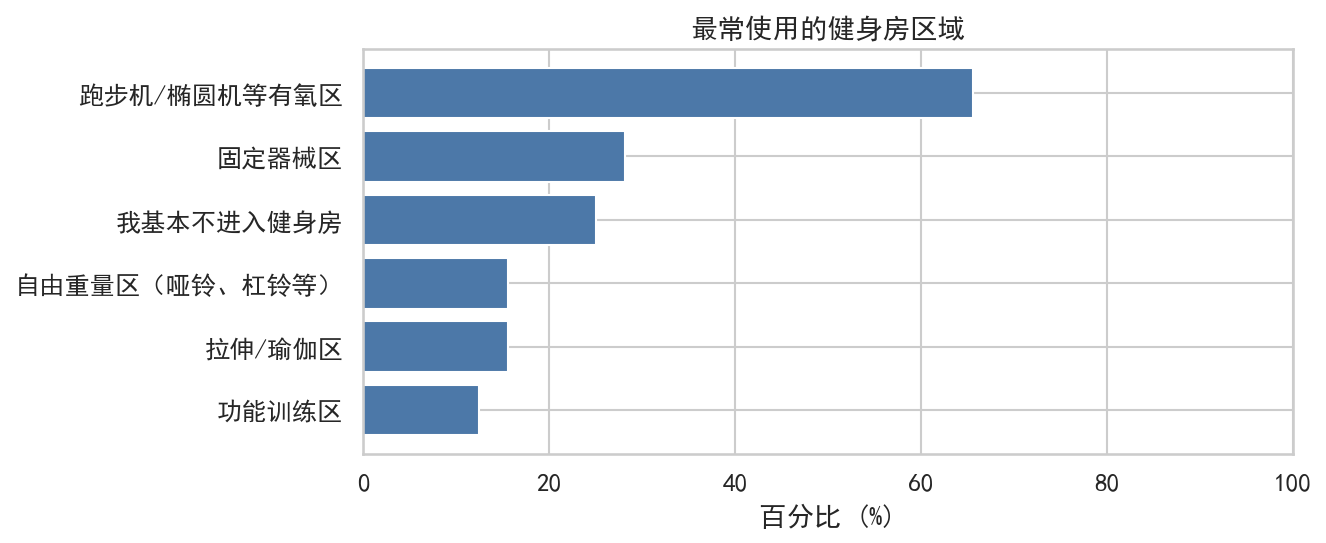

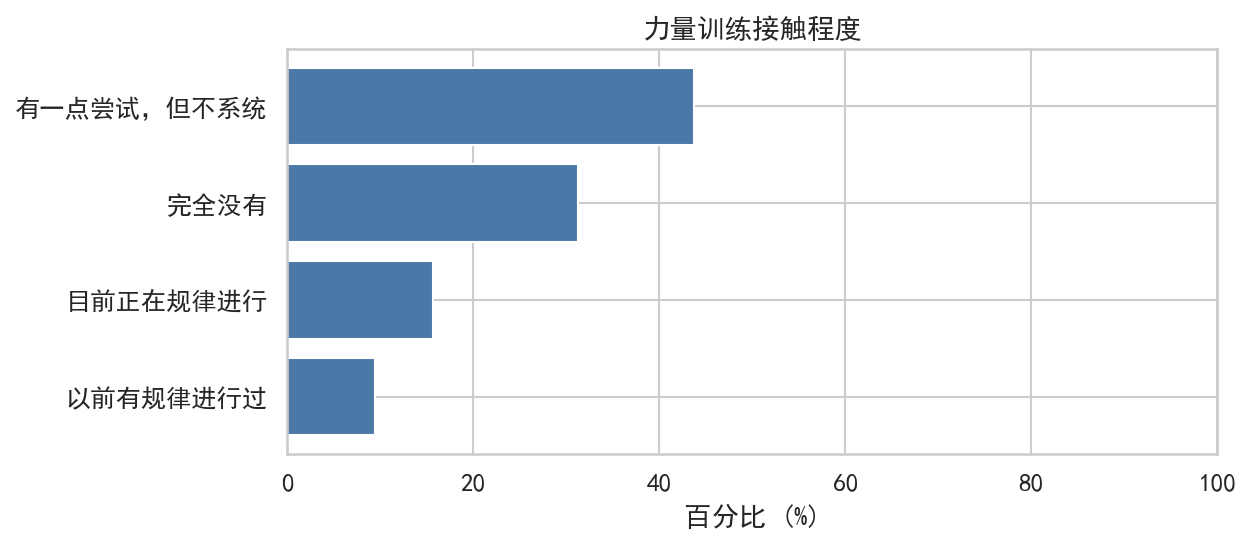

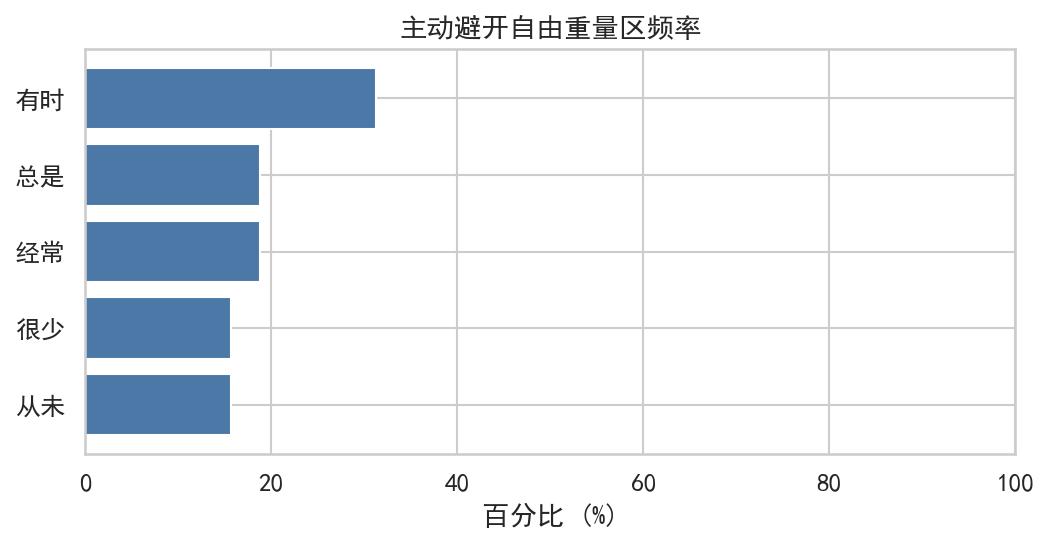

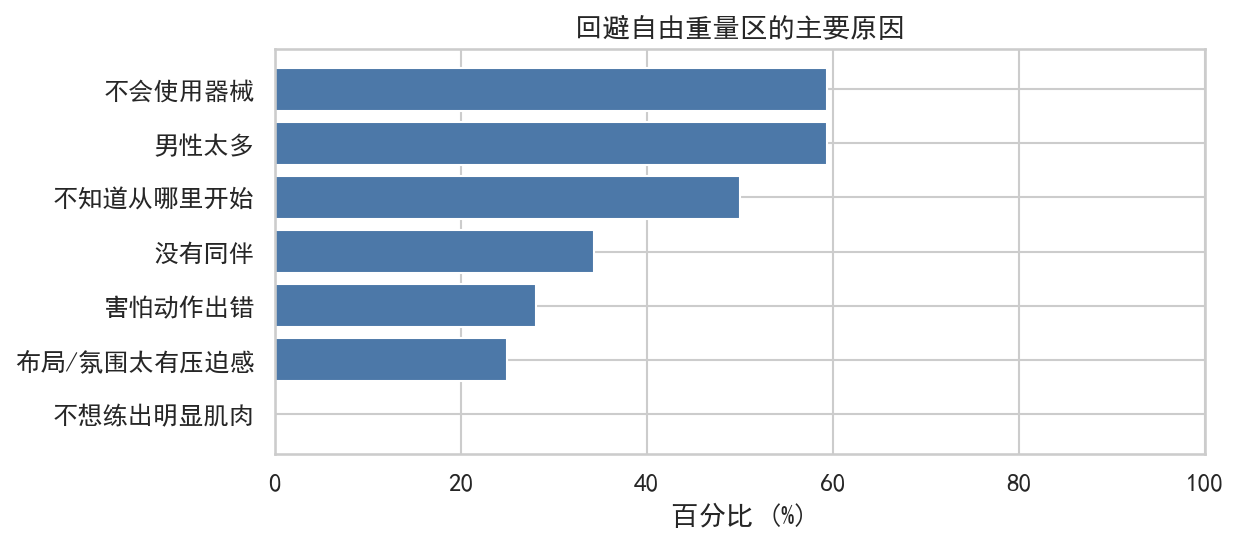

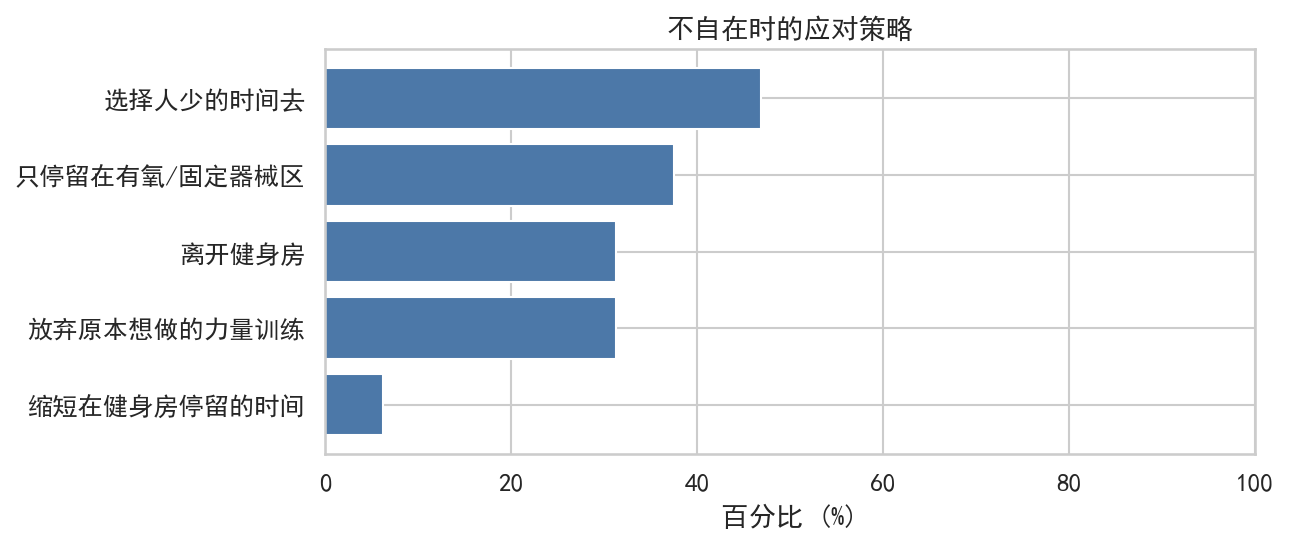

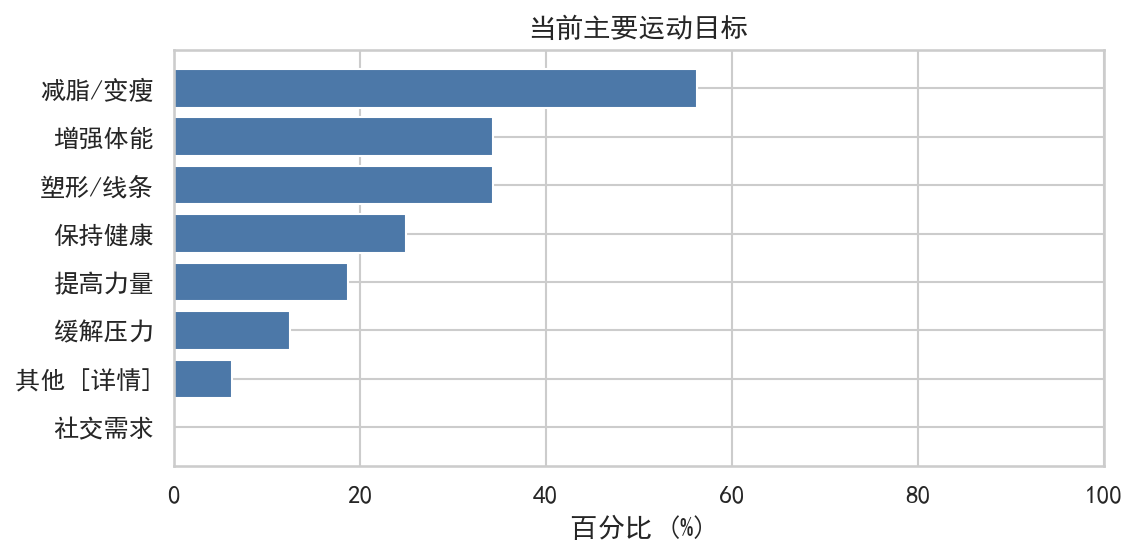

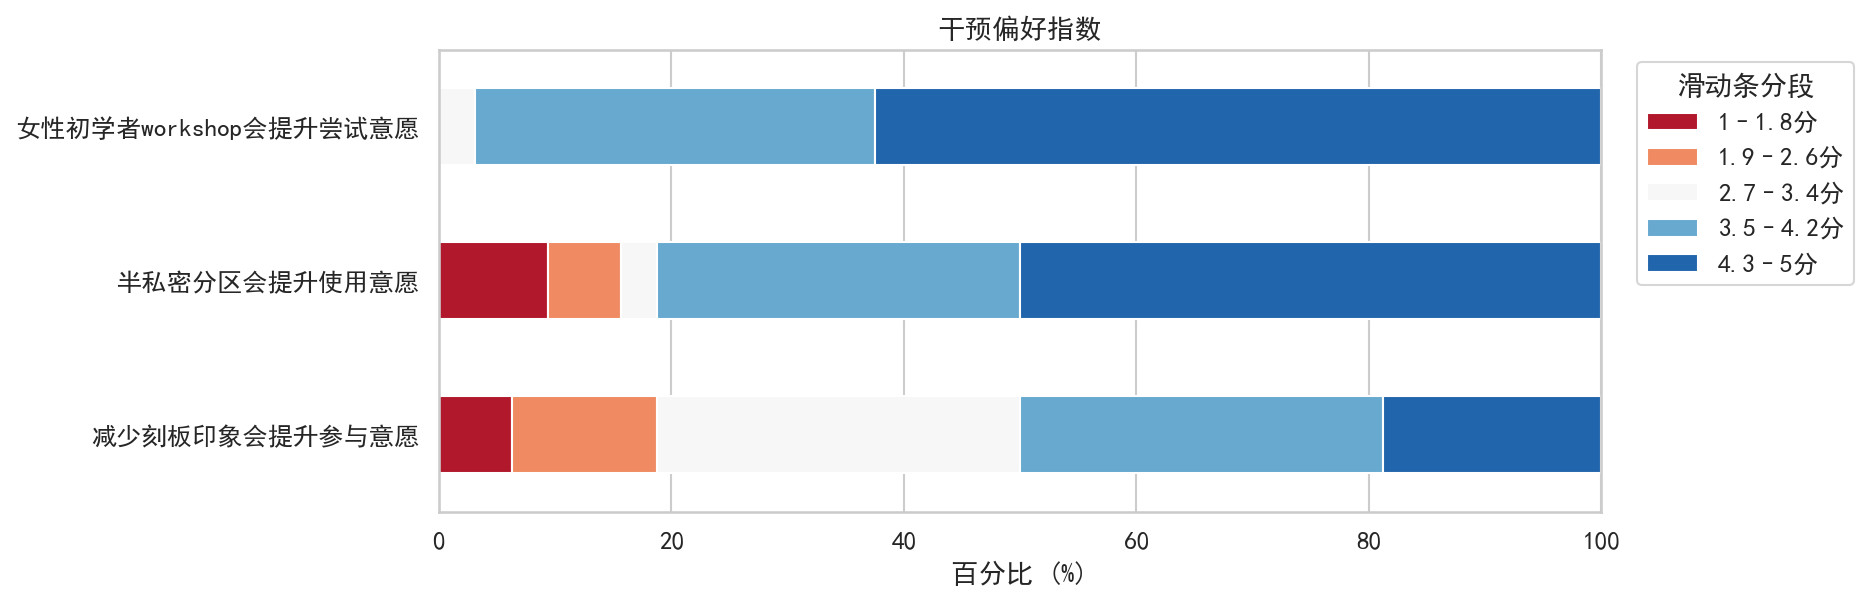

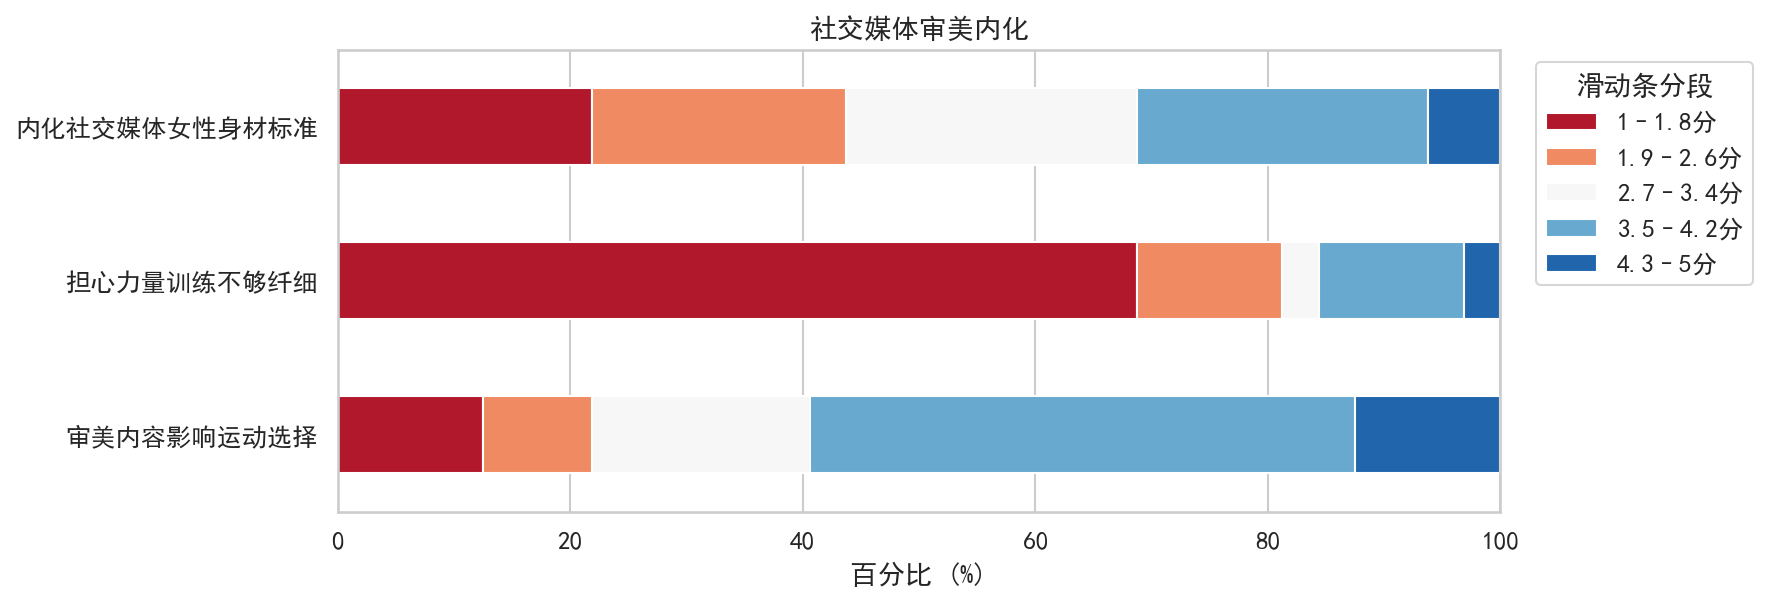

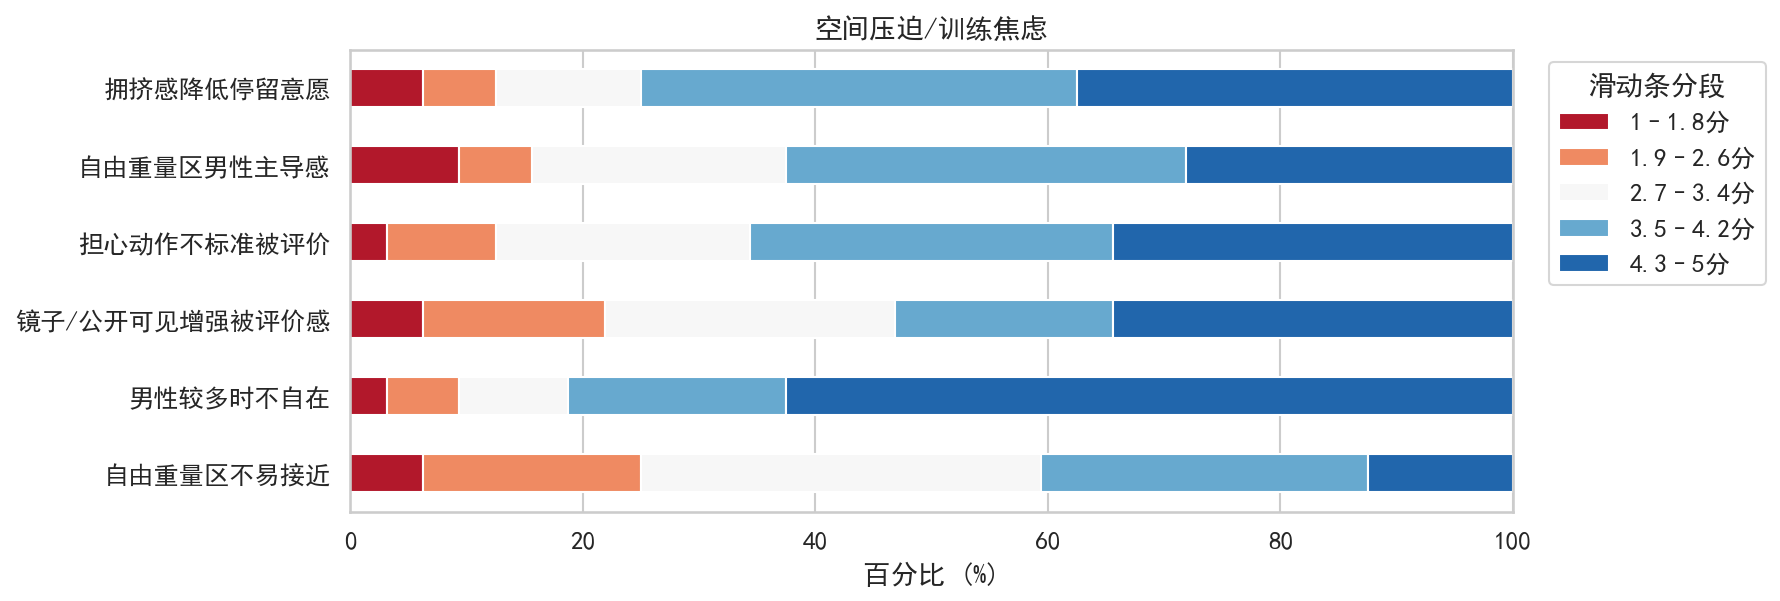

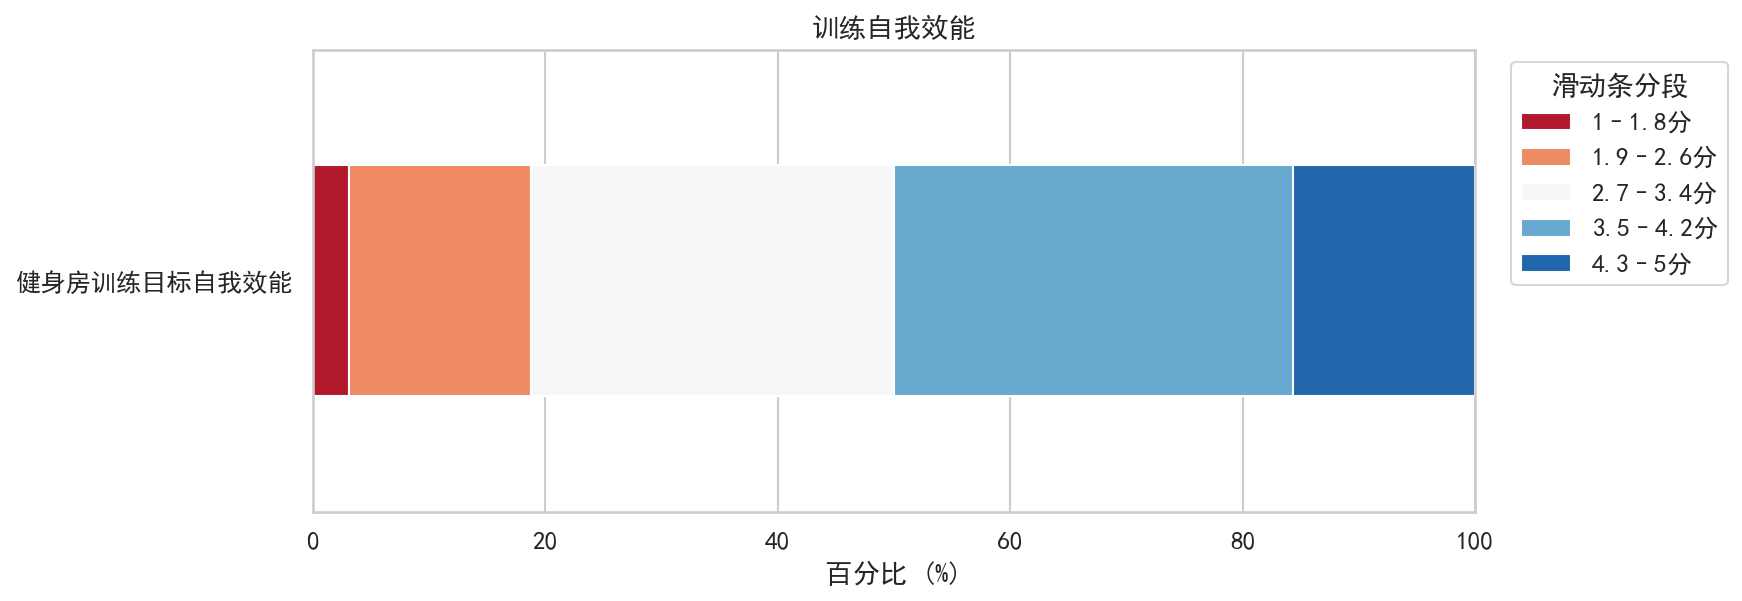

In [4]:
for q_num, filename, title in [
    (7, "gym_area_use.png", "最常使用的健身房区域"),
    (8, "strength_training_experience.png", "力量训练接触程度"),
    (16, "free_weight_avoidance.png", "主动避开自由重量区频率"),
    (17, "avoidance_reasons.png", "回避自由重量区的主要原因"),
    (18, "coping_strategies.png", "不自在时的应对策略"),
    (9, "exercise_goals.png", "当前主要运动目标"),
]:
    fig = horizontal_frequency_plot(frequency_table(options, q_num), title=title)
    fig.savefig(fig_dir / filename, dpi=200)

slider_options = options[options["kind"].eq("bin")]
for construct, frame in sliders.groupby("construct", dropna=True):
    q_nums = frame["q_num"].tolist()
    fig = slider_distribution_plot(
        slider_options[slider_options["q_num"].isin(q_nums)],
        QUESTION_LABELS,
        title=construct,
    )
    aliases = {
        "空间压迫/训练焦虑": "spatial_anxiety",
        "社交媒体审美内化": "media_internalization",
        "训练自我效能": "training_self_efficacy",
        "干预偏好指数": "intervention_acceptance",
    }
    fig.savefig(fig_dir / f"slider_{aliases.get(construct, construct)}.png", dpi=200)
    print(construct, q_nums)